In [1]:
import numpy as np
import torch
import torch.nn as nn

import sys
sys.path.insert(0, '../src')

from plot import plot_wavefunction, plot_wavefunctions
from sampling import TrainConfig
from scipy_eigensolver import solve_1channel
from training import train_Rayleigh, train_Rayleigh_PDE
from validation import validate, print_metrics

Define parameters

In [2]:
g = 8.22
a = 1.5 
mu = 1.0/a

r_min = 1e-4
r_max = 30.0
r = np.linspace(r_min, r_max, 1000)

Solve with scipy

Ground state energy E = -2.222665 MeV


/Users/phongdang/Desktop/AI-JC/Second_data_challenge/Project3_Nuclear_Physics/test/../src/scipy_eigensolver.py:48: RuntimeWarning: overflow encountered in scalar multiply
  if u_vals[i] * u_vals[i+1] < 0:


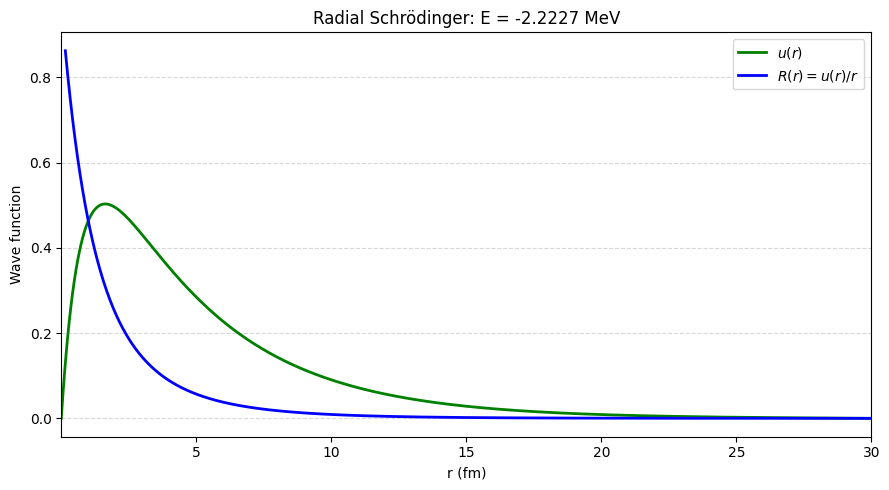

In [3]:
def V(r):
    return - g**2 * np.exp(-mu * r) /  np.maximum(r, 1e-2)

E_scipy, u_scipy, R_scipy = solve_1channel(V, r)
plot_wavefunction(r, u_scipy, R_scipy, E_scipy)

Define a neural network $N_\theta(r)$ that approximates the radial wave function via an ansatz
$$
u_\theta(r) = r e^{-\alpha r} N_{\theta}(r) \text{ with } \alpha = 0.25 \text{ fm}^{-1}.
$$
The network input is rescaled from $[0,r_{\max}]$ to $[-1,1]$.

In [4]:
class RadialNet(nn.Module):
    def __init__(self, hidden_dim=64, num_layers=3, alpha=0.25, energy_init=-3.0):
        # Define layers
        super().__init__()
        layers = [nn.Linear(1, hidden_dim), nn.Tanh()]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.Tanh()]
        layers.append(nn.Linear(hidden_dim, 1))
        self.net = nn.Sequential(*layers)

        self.register_buffer('alpha', torch.tensor(float(alpha)))
        self.energy = nn.Parameter(torch.tensor([energy_init], dtype=torch.float32))

        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        self.dtype = torch.float32

        self.r_min = r_min
        self.r_max = r_max
        self.R = None

    # Forward pass
    def forward(self, r):
        # r is expected to be of shape (N, 1)
        x = 2.0 * r / self.r_max - 1.0 # mapping to [-1,1]
        return r * torch.exp(-self.alpha * r) * self.net(x)

    # Potential
    def potential(self, r):
        return -g**2 * torch.exp(-mu * r) / r

Train with Rayleigh energy only

In [5]:
cfg = TrainConfig()
cfg.n_rayleigh = 8000

model = RadialNet()

history = train_Rayleigh(model, cfg, stop=1e-3)

{'step': 1, 'loss': 1.7392094135284424, 'rayleigh': -0.5698022246360779, 'norm_loss': 0.23089730739593506, 'boundary_loss': 3.8652506191283464e-06, 'E': -0.5698022246360779}
{'step': 500, 'loss': -2.363861322402954, 'rayleigh': -2.3969850540161133, 'norm_loss': 0.003311846172437072, 'boundary_loss': 5.194245318307367e-07, 'E': -2.3969850540161133}
{'step': 1000, 'loss': -2.919607400894165, 'rayleigh': -2.921349048614502, 'norm_loss': 0.00017396119073964655, 'boundary_loss': 2.2564856294593483e-07, 'E': -2.921349048614502}
{'step': 1500, 'loss': -2.1212449073791504, 'rayleigh': -2.150527000427246, 'norm_loss': 0.0029279105365276337, 'boundary_loss': 3.19113922842007e-07, 'E': -2.150527000427246}
{'step': 2000, 'loss': -2.7457337379455566, 'rayleigh': -2.745823383331299, 'norm_loss': 7.408121746266261e-06, 'boundary_loss': 1.552859316689137e-06, 'E': -2.745823383331299}
{'step': 2500, 'loss': -2.988800048828125, 'rayleigh': -2.996995210647583, 'norm_loss': 0.0008187976200133562, 'boundar

In [6]:
metrics, u_nn, R_nn = validate(r, u_scipy, R_scipy, E_scipy, model)
print_metrics(metrics)

  rayleigh_energy: -2.209549
  norm_loss: 0.0017868087
  pde_loss: 0.17906305
  u_rmax: -0.0010387721
  l2: 0.02682491
  learned_energy: -2.2439919
  energy_error: 0.021327004


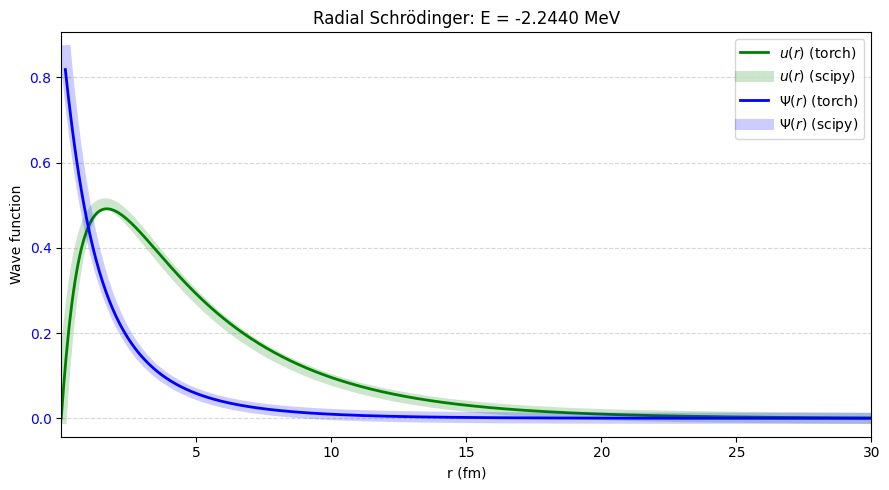

In [7]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn, R_nn, metrics['learned_energy'])

Train with both Rayleigh and PDE terms

In [17]:
cfg2 = TrainConfig()
cfg2.n_origin = 2000
cfg2.n_pde = 3000
cfg2.origin_width = 0.6

model2 = RadialNet()

history2 = train_Rayleigh_PDE(model2, cfg2, stop=1e-3)

{'step': 1, 'loss': 5.946177005767822, 'rayleigh': -0.7157583832740784, 'pde_loss': 6.2704758644104, 'match_loss': 5.21776008605957, 'norm_loss': 0.6661931872367859, 'boundary_loss': 3.429230446272413e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 500, 'loss': -2.0501348972320557, 'rayleigh': -2.066549301147461, 'pde_loss': 24.8889102935791, 'match_loss': 0.871330201625824, 'norm_loss': 0.0016413063276559114, 'boundary_loss': 1.3927311215411464e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1000, 'loss': -1.0558565855026245, 'rayleigh': -1.0880342721939087, 'pde_loss': 7.6403913497924805, 'match_loss': 3.6556129455566406, 'norm_loss': 0.0032170116901397705, 'boundary_loss': 7.474368430848699e-07, 'E': -3.0, 'lambda_pde': 0.0, 'lambda_match': 0.0}
{'step': 1500, 'loss': -2.7927403450012207, 'rayleigh': -2.7988362312316895, 'pde_loss': 15.806941986083984, 'match_loss': 0.04046686366200447, 'norm_loss': 0.0006095858989283442, 'boundary_loss': 1.86821935

In [18]:
metrics2, u_nn2, R_nn2 = validate(r, u_scipy, R_scipy, E_scipy, model2)
print_metrics(metrics2)

  rayleigh_energy: -2.1828058
  norm_loss: 0.0011265482
  pde_loss: 0.016318928
  u_rmax: -0.0020522897
  l2: 0.081820039
  learned_energy: -2.2142475
  energy_error: 0.0084173828


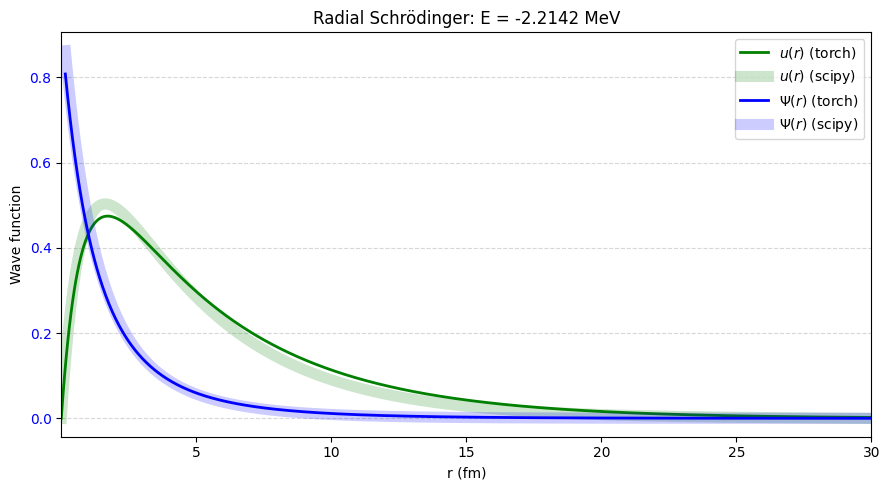

In [19]:
plot_wavefunctions(r, u_scipy, R_scipy, u_nn2, R_nn2, metrics2['learned_energy'])